<a href="https://colab.research.google.com/github/JakeOh/202511_BD53/blob/main/lab_ml/ml19_cnn_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [18]:
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import keras
import tensorflow as tf

In [3]:
tf.__version__

'2.19.0'

In [4]:
keras.__version__

'3.13.2'

In [2]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# CNN 연습 1

*   Keras 패키지의 Fashion MNIST 데이터 셋
    *   훈련 셋과 테스트 셋의 데이터는 0. ~ 1. 스케일로 스케일링
*   CNN 모델 구조
    *   Conv2D(filters=64, kernel_size=7)
    *   MaxPool2D
    *   Conv2D(filters=128, kernel_size=3)
    *   Conv2D(filters=128, kernel_size=3)
    *   MaxPool2D
    *   Conv2D(filters=256, kernel_size=3)
    *   Conv2D(filters=256, kernel_size=3)
    *   MaxPool2D
    *   Flatten
    *   Dense(units=128)
    *   Dropout(rate=0.5)
    *   Dense(units=64)
    *   Dropout(rate=0.5)
    *   Dense - 출력층
    *   출력층을 제외한 층(Conv2D, Dense)들의 활성화 함수는 ReLU
    *   합성곱 층의 `padding` 방식은 'same' 방식.
    *   합성곱 층의 커널 초기화 함수(`kernel_initializer`)는 'he_normal'
*   모델 컴파일 시 `optimizer`는 Nadam으로 설정.
*   ModelCheckpoint, EarlyStopping 콜백을 사용해서 모델 훈련을 조기 종료하고, 최적의 모델은 best_cnn1.keras 파일에 저장.
*   각 에포크에서의 손실 함수를 시각화.
*   모델 성능 평가

## Fashion MNIST Datasets

In [5]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
x_train_full.shape

(60000, 28, 28)

In [7]:
x_test.shape

(10000, 28, 28)

In [8]:
# 훈련 셋과 테스트 셋을 (n_samples, height, width, channels) 모양으로 변환하고 0.0 ~ 1.0 스케일로 바꿈.
x_train_full_scaled = x_train_full.reshape((-1, 28, 28, 1)) / 255.0
x_test_scaled = x_test.reshape((-1, 28, 28, 1)) / 255.0

In [10]:
# 전체 훈련 셋을 훈련/검증 셋으로 분리
x_train, x_val, y_train, y_val = train_test_split(x_train_full_scaled, y_train_full,
                                                  test_size=0.1,
                                                  stratify=y_train_full,
                                                  random_state=42)

In [11]:
x_train.shape

(54000, 28, 28, 1)

In [12]:
x_val.shape

(6000, 28, 28, 1)

## CNN 모델 생성

In [13]:
tf.random.set_seed(42)
np.random.seed(42)

In [14]:
cnn_1 = keras.Sequential(layers=[
    keras.Input(shape=(28, 28, 1)),
    keras.layers.Conv2D(filters=64, kernel_size=7, padding='same',
                        activation='relu', kernel_initializer='he_normal'),
    keras.layers.MaxPool2D(pool_size=2),
    keras.layers.Conv2D(filters=128, kernel_size=3, padding='same',
                        activation='relu', kernel_initializer='he_normal'),
    keras.layers.Conv2D(filters=128, kernel_size=3, padding='same',
                        activation='relu', kernel_initializer='he_normal'),
    keras.layers.MaxPool2D(pool_size=2),
    keras.layers.Conv2D(filters=256, kernel_size=3, padding='same',
                        activation='relu', kernel_initializer='he_normal'),
    keras.layers.Conv2D(filters=256, kernel_size=3, padding='same',
                        activation='relu', kernel_initializer='he_normal'),
    keras.layers.MaxPool2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu', kernel_initializer='he_normal'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=64, activation='relu', kernel_initializer='he_normal'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax')
])

In [15]:
cnn_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,413,834 (5.39 MB)

 Trainable params: 1,413,834 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

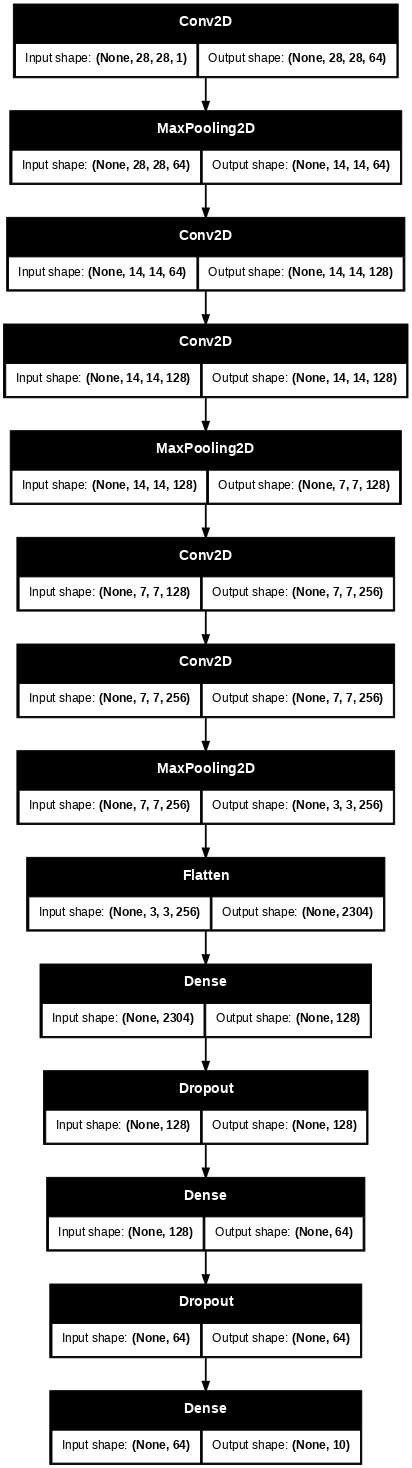

In [16]:
keras.utils.plot_model(model=cnn_1, dpi=64, show_shapes=True)

In [17]:
cnn_1.compile(optimizer=keras.optimizers.Nadam(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

## CNN 모델 훈련

In [20]:
dir = '/content/drive/MyDrive/Colab Notebooks/lab_ml'
file_name = 'best_cnn1'
suffix = datetime.now().strftime('%Y%m%d%H%M%S')  # (예) 20260319143000
file_path = f'{dir}/{file_name}_{suffix}.keras'
print(file_path)

/content/drive/MyDrive/Colab Notebooks/lab_ml/best_cnn1_20260319051349.keras


In [21]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(filepath=file_path, save_best_only=True)
early_stop_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

In [23]:
result = cnn_1.fit(x=x_train, y=y_train, batch_size=64, epochs=1_000,
                   validation_data=[x_val, y_val],
                   callbacks=[checkpoint_cb, early_stop_cb])

Epoch 1/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - loss: 0.8234 - sparse_categorical_accuracy: 0.7149 - val_loss: 0.4189 - val_sparse_categorical_accuracy: 0.8542
Epoch 2/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.4495 - sparse_categorical_accuracy: 0.8485 - val_loss: 0.3170 - val_sparse_categorical_accuracy: 0.8910
Epoch 3/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.3728 - sparse_categorical_accuracy: 0.8756 - val_loss: 0.3028 - val_sparse_categorical_accuracy: 0.8928
Epoch 4/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.3251 - sparse_categorical_accuracy: 0.8926 - val_loss: 0.2604 - val_sparse_categorical_accuracy: 0.9095
Epoch 5/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.2950 - sparse_categorical_accuracy: 0.9010 - val_loss: 0.2480 - val_sparse_categorical_accuracy: 0.9123
Epoch 6/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.2598 - sparse_categorical_accuracy: 0.9116 - val_loss: 0.2413 - val_sparse_categoric

In [24]:
def plot_train_val_loss(history):
    # 파라미터 history: fit 메서드 리턴값(History 타입 객체)
    epochs = history.epoch
    history = history.history
    plt.plot(epochs, history['loss'], 'bo-', label='train loss')
    plt.plot(epochs, history['val_loss'], 'ro:', label='validation loss')
    plt.legend()
    plt.grid()
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.show()

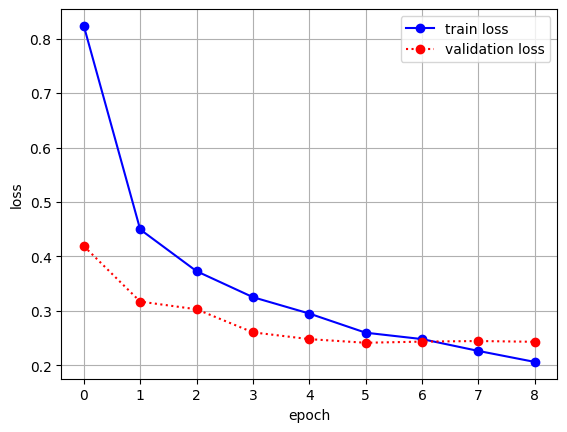

In [25]:
plot_train_val_loss(result)

## CNN 모델 평가

In [26]:
# 훈련 셋 평가(손실, 정확도)
cnn_1.evaluate(x=x_train, y=y_train)

1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.1968 - sparse_categorical_accuracy: 0.9297


[0.19683143496513367, 0.9297407269477844]

In [27]:
# 검증 셋 평가
cnn_1.evaluate(x=x_val, y=y_val)

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2413 - sparse_categorical_accuracy: 0.9172


[0.24131596088409424, 0.9171666502952576]

# CNN 연습 2

*   Keras 패키지의 손글씨 MNIST 예제 데이터셋
    *   예제 데이터셋의 일부(예: 100개)를 시각화.
    *   훈련 셋과 테스트 셋의 데이터는 0. ~ 1. 스케일로 스케일링.
*   CNN 모델 구조
    *   Conv2D(filters=32, kernel_size=3)
    *   Conv2D(filters=64, kernel_size=3)
    *   MaxPool2D
    *   Flatten
    *   Dropout(rate=0.25)
    *   Dense(units=128)
    *   Dropout(rate=0.5)
    *   Dense - 출력층
*   모든 합성곱 층(Conv2D)와 출력층을 제외한 밀집층(Dense)에서
    *   활성화 함수(`activation`)는 ReLU로 설정.
    *   커널 초기화 함수(`kernel_initializer`)를 'he_normal'로 설정.
*   모델의 옵티마이저(`optimizer`)는 Nadam을 사용.
*   ModelCheckpoint, EarlyStopping 콜백을 함께 사용해서 모델을 훈련을 조기종료 하고, 최적의 모델은 best_cnn2.keras 파일에 저장.
*   각 에포크에서의 손실 함수를 시각화.
*   모델의 성능을 평가.

## 손글씨 MNIST Datasets

In [28]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [29]:
x_train_full.shape

(60000, 28, 28)

In [30]:
x_test.shape

(10000, 28, 28)

In [31]:
def plot_mnist_image(arr, ncols=10):
    # arr: (n_samples, height, width) 모양의 배열.
    n_samples = len(arr)
    nrows = int(np.ceil(n_samples / ncols))
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols, nrows))
    for i in range(nrows):
        for j in range(ncols):
            idx = i * ncols + j
            if nrows == 1 or ncols == 1:
                if idx < n_samples:
                    ax[idx].imshow(arr[idx], cmap=plt.cm.binary)
                ax[idx].axis('off')
            else:
                if idx < n_samples:
                    ax[i, j].imshow(arr[idx], cmap=plt.cm.binary)
                ax[i, j].axis('off')
    plt.show()

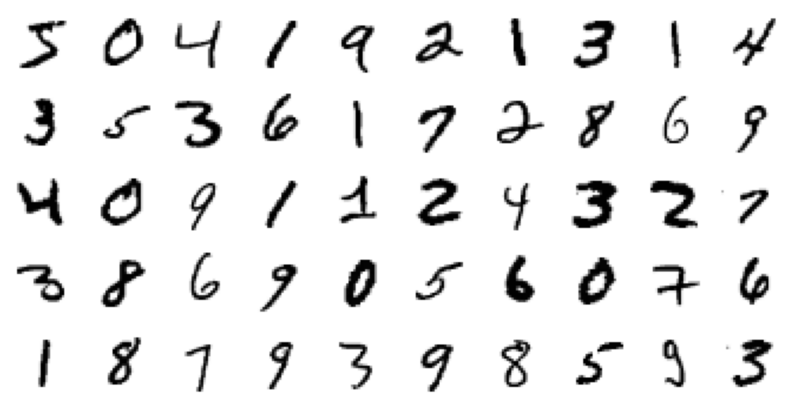

In [32]:
plot_mnist_image(x_train_full[:50])

In [33]:
# 훈련 셋과 테스트 셋의 모양은 (n_samples, height, width, channels), 스케일은 0.0 ~ 1.0으로 변환
x_train_full_scaled = x_train_full.reshape((-1, 28, 28, 1)) / 255.0
x_test_scaled = x_test.reshape((-1, 28, 28, 1)) / 255.0

In [34]:
# 전체 훈련 셋을 훈련/검증 셋으로 분리
x_train, x_val, y_train, y_val = train_test_split(x_train_full_scaled, y_train_full,
                                                  test_size=0.1,
                                                  stratify=y_train_full,
                                                  random_state=42)

In [35]:
x_train.shape

(54000, 28, 28, 1)

In [36]:
x_val.shape

(6000, 28, 28, 1)

## CNN 모델 생성

In [37]:
tf.random.set_seed(42)
np.random.seed(42)

In [38]:
cnn_2 = keras.Sequential(layers=[
    keras.Input(shape=(28, 28, 1)),
    keras.layers.Conv2D(filters=32, kernel_size=3, padding='same',
                        activation='relu', kernel_initializer='he_normal'),
    keras.layers.Conv2D(filters=64, kernel_size=3, padding='same',
                        activation='relu', kernel_initializer='he_normal'),
    keras.layers.MaxPool2D(),
    keras.layers.Flatten(),
    keras.layers.Dropout(rate=0.25),
    keras.layers.Dense(units=128, activation='relu', kernel_initializer='he_normal'),  # 밀집층
    keras.layers.Dropout(rate=0.5),
    keras.layers.Dense(units=10, activation='softmax')
])

In [39]:
cnn_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,866 (6.20 MB)

 Trainable params: 1,625,866 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

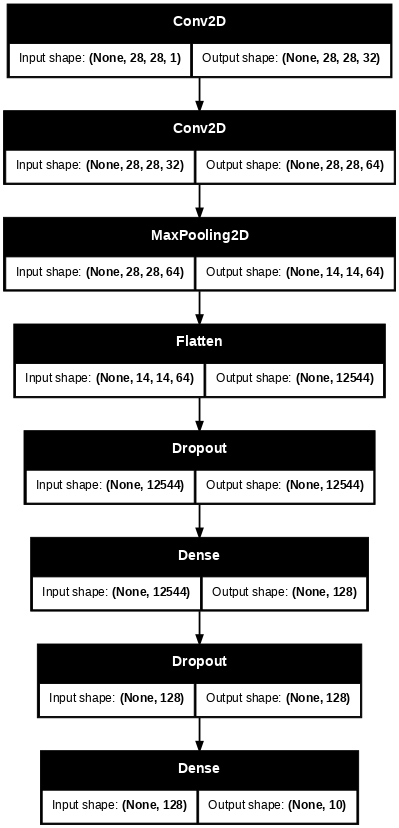

In [41]:
keras.utils.plot_model(model=cnn_2, show_shapes=True, dpi=64)

## 모델 훈련

In [47]:
# 모델 컴파일
cnn_2.compile(optimizer=keras.optimizers.Nadam(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [48]:
dir = '/content/drive/MyDrive/Colab Notebooks/lab_da'
file_name = 'best_cnn2'
time_suffix = datetime.now().strftime('%Y%m%d%H%M%S')
file_path = f'{dir}/{file_name}_{time_suffix}.keras'
print(file_path)

/content/drive/MyDrive/Colab Notebooks/lab_da/best_cnn2_20260319053105.keras


In [49]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(filepath=file_path, save_best_only=True)
early_stop_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

In [50]:
result = cnn_2.fit(x=x_train, y=y_train, batch_size=64, epochs=1_000,
                   callbacks=[checkpoint_cb, early_stop_cb],
                   validation_data=[x_val, y_val])

Epoch 1/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.2278 - sparse_categorical_accuracy: 0.9317 - val_loss: 0.0672 - val_sparse_categorical_accuracy: 0.9808
Epoch 2/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0885 - sparse_categorical_accuracy: 0.9743 - val_loss: 0.0604 - val_sparse_categorical_accuracy: 0.9855
Epoch 3/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0692 - sparse_categorical_accuracy: 0.9787 - val_loss: 0.0487 - val_sparse_categorical_accuracy: 0.9872
Epoch 4/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0525 - sparse_categorical_accuracy: 0.9836 - val_loss: 0.0535 - val_sparse_categorical_accuracy: 0.9863
Epoch 5/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0453 - sparse_categorical_accuracy: 0.9854 - val_loss: 0.0490 - val_sparse_categorical_accuracy: 0.9875
Epoch 6/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0365 - sparse_categorical_accuracy: 0.9885 - val_loss: 0.0563 - val_sparse_categorical_accuracy

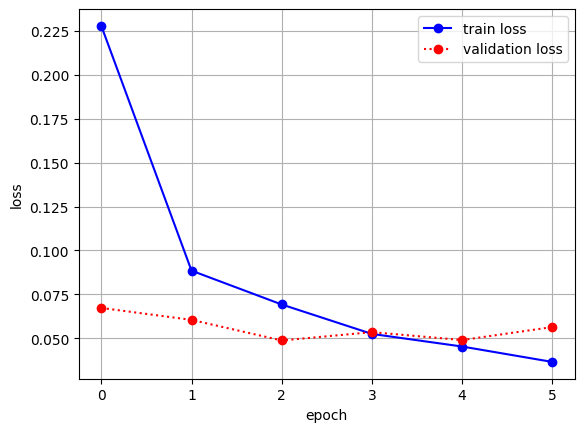

In [51]:
plot_train_val_loss(result)

## 모델 평가

In [53]:
# 훈련 셋 평가
cnn_2.evaluate(x=x_train, y=y_train)

1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0188 - sparse_categorical_accuracy: 0.9941


[0.01881328411400318, 0.9940740466117859]

In [54]:
# 검증 셋 평가
cnn_2.evaluate(x=x_val, y=y_val)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0487 - sparse_categorical_accuracy: 0.9872


[0.04871624708175659, 0.9871666431427002]

유명한 CNN
*   LeNet-5
*   AlexNet
*   GoogLeNet
*   VGGNet
*   ResNet
*   Xception
*   SENet